In [ ]:
# Importing libraries which is needed

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [3]:
# Reading Mibor rates file
# Using data.head() for checking out first rows of data

In [4]:
import pandas as pd

data = pd.read_excel("Mibor.xls", skiprows=2)

data.head()

C:\Users\abhay\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,Date,Tenor,Time,Overnight MIBOR(%),Comments
0,27 Feb 2026,O/N,12:45:00 PM,5.17,NaN
1,26 Feb 2026,O/N,12:45:00 PM,5.13,NaN
2,25 Feb 2026,O/N,12:45:00 PM,5.14,NaN
3,24 Feb 2026,O/N,12:45:00 PM,5.17,NaN
4,23 Feb 2026,O/N,12:45:00 PM,5.17,NaN


In [5]:
# Dropping unwanted columns which is not needed

In [6]:
data = data[['Date','Overnight MIBOR(%)']]

data['Date'] = pd.to_datetime(data['Date'])             #Changing date format

data = data.sort_values('Date')

data = data.dropna()

rates = data['Overnight MIBOR(%)'].values / 100

In [7]:
data.head(5)

,Date,Overnight MIBOR(%)
500,2024-02-01,6.85
499,2024-02-02,6.66
498,2024-02-05,6.54
497,2024-02-06,6.55
496,2024-02-07,6.55


In [ ]:
#Plotting Overnight Mibor 

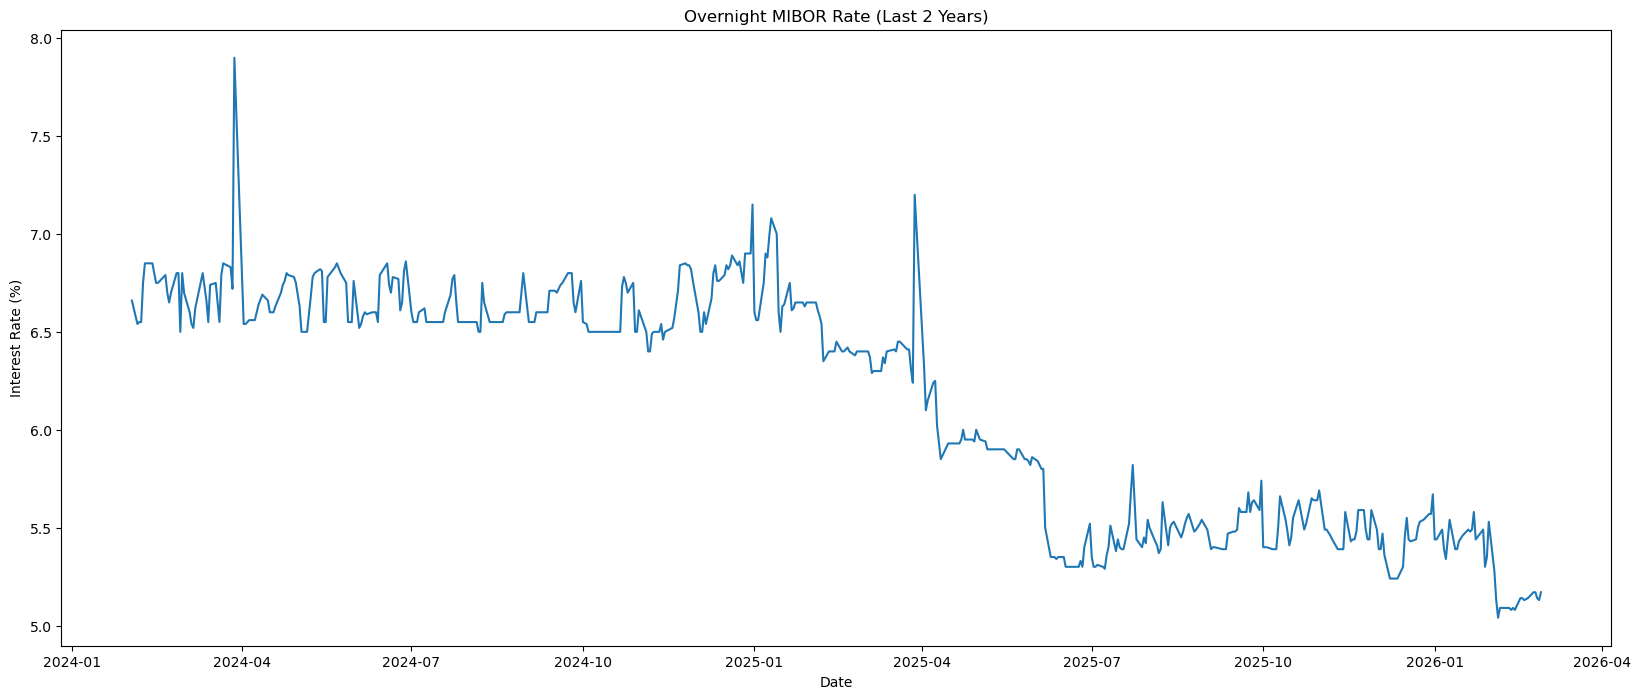

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20,8))

plt.plot(data['Date'], data['Overnight MIBOR(%)'])

plt.title("Overnight MIBOR Rate (Last 2 Years)")
plt.xlabel("Date")
plt.ylabel("Interest Rate (%)")

plt.show()

In [9]:
data = data[data['Date'] >= "2024-01-01"]

In [10]:
data = data.tail(500)

In [11]:
data = pd.read_excel("Mibor.xls", skiprows=2)

data = data[['Date','Overnight MIBOR(%)']]

data['Date'] = pd.to_datetime(data['Date'])

data = data.sort_values('Date')

data = data.tail(500)

rates = data['Overnight MIBOR(%)'].values / 100

C:\Users\abhay\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


In [12]:
import numpy as np

rates = data['Overnight MIBOR(%)'].values / 100

r_t = rates[:-1]
r_t1 = rates[1:]

dt = 1/252   # daily financial data assumption

In [1]:
#dr_t = a(b - r_t)dt + sigma dW_t
#Equation for vasicek model where: r_t is interest rate at time t, dr_t is small change in int rate, a(b - r_t)dt is mean reversion part (Int rate below b- move up and int rate above b- mode down
#sigma is volatility of int rates and dwt is brownian motion (random shock)

In [14]:
# Flow : Interest rate data > Linear regression > Beta coefficients > Convert to vasicrk parameters > a, b , sigma

X = np.vstack([np.ones(len(r_t)), r_t]).T

beta = np.linalg.lstsq(X, r_t1, rcond=None)[0]

a = -np.log(beta[1]) / dt                             # Calculate mean reversion speed
b = beta[0] / (1 - beta[1])

sigma = np.std(r_t1 - beta[0] - beta[1]*r_t) / np.sqrt(dt)    #Estimating volatility, divide by root dt to scale correctly

print("Vasicek Parameters")
print("a (mean reversion):", a)
print("b (long term mean):", b)
print("sigma (volatility):", sigma)

Vasicek Parameters
a (mean reversion): 6.136986534872924
b (long term mean): 0.06016069846717243
sigma (volatility): 0.021211741002561575


In [15]:
def vasicek_simulation(r0, a, b, sigma, T, steps):        #r0 is initial int rate, a: Mean reversion speed, b: lomg term mean, sigma: volatility, T: Time

    dt = T/steps                                          # Small time intervals
    rates = np.zeros(steps)                               #Creating empty array to store int rates
    rates[0] = r0                                         #Setting intial rate

    for i in range(1, steps):                             #Day 1> Day 2> Day 3

        dr = a*(b - rates[i-1])*dt + sigma*np.sqrt(dt)*np.random.normal()       #Core of vasicek simulation
                                                                                #a*(b - rates[i-1])*dt: rate below b- goes up, rate above b- goes down
                                                                                #sigma*np.sqrt(dt)*np.random.normal()- Random number, Sigma and time scaling                                                                     
        rates[i] = rates[i-1] + dr                         #Old rate + Change

    return rates

In [16]:
T = 6                            #For 6 years
steps = 1500                     #Simulation steps
vasicek_rates = vasicek_simulation(rates[-1], a, b, sigma, T, steps)      #rates[-1]: Current rate

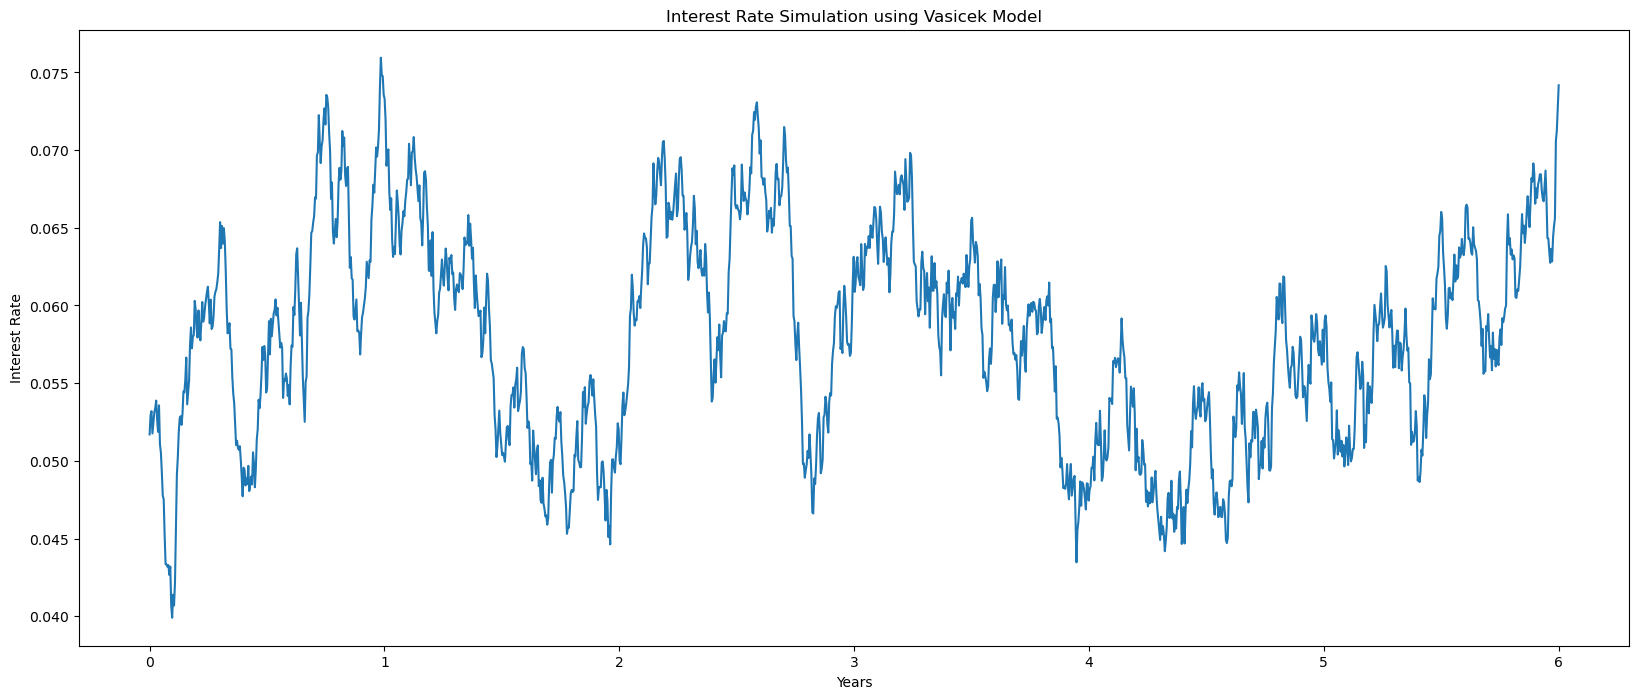

In [29]:
import matplotlib.pyplot as plt

time = np.linspace(0, T, steps)

plt.figure(figsize=(20,8))

plt.plot(time, vasicek_rates)

plt.title("Interest Rate Simulation using Vasicek Model")

plt.xlabel("Years")
plt.ylabel("Interest Rate")

plt.show()

In [18]:
periods = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5]

for p in periods:

    idx = int(p/T * steps)

    print("Year:", p)
    print("Predicted Rate:", vasicek_rates[idx])
    print()

Year: 0.5
Predicted Rate: 0.05468732609736975

Year: 1
Predicted Rate: 0.0733056187382139

Year: 1.5
Predicted Rate: 0.050374424181278146

Year: 2
Predicted Rate: 0.049982646584209305

Year: 2.5
Predicted Rate: 0.06645244835727371

Year: 3
Predicted Rate: 0.060878244837899845

Year: 3.5
Predicted Rate: 0.06564766392026168

Year: 4
Predicted Rate: 0.04814774441652797

Year: 4.5
Predicted Rate: 0.05348059729921514

Year: 5
Predicted Rate: 0.05901095549643821

Year: 5.5
Predicted Rate: 0.06563114449736314



In [20]:
#dr_t = (theta(t) - a r_t)dt + sigma dW_t
# a	Mean reversion speed
# sigma	Volatility
# theta(t)	Time-dependent drift

# theta = a × b
# Where b is the long-term mean from Vasicek.

In [21]:
def hull_white_simulation(r0, a, sigma, theta, T, steps):

    dt = T / steps
    
    rates = np.zeros(steps)
    rates[0] = r0

    for i in range(1, steps):

        dr = (theta - a * rates[i-1]) * dt + sigma * np.sqrt(dt) * np.random.normal()

        rates[i] = rates[i-1] + dr

    return rates

In [22]:
theta = a * b

hw_rates = hull_white_simulation(rates[-1], a, sigma, theta, T, steps)

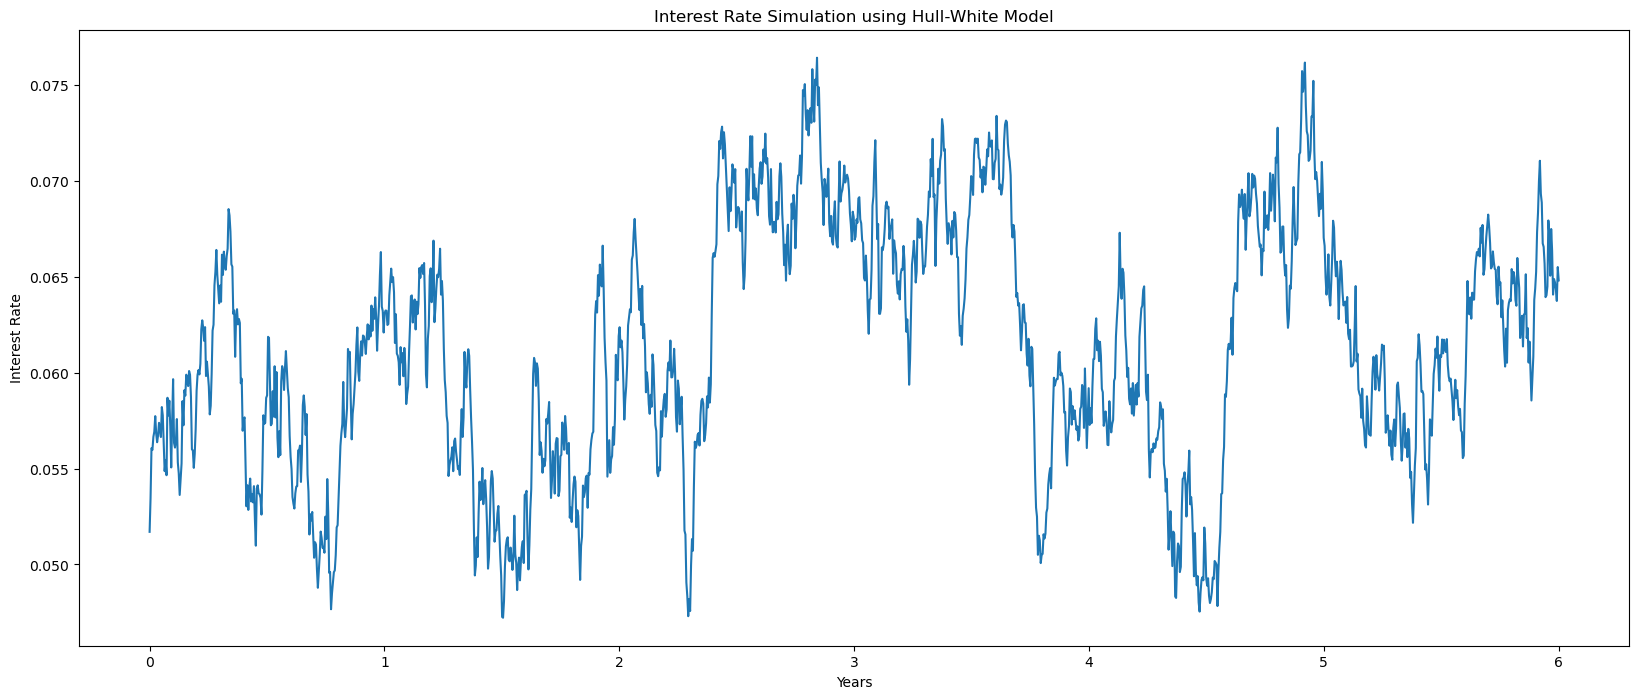

In [28]:
time = np.linspace(0, T, steps)

plt.figure(figsize=(20,8))

plt.plot(time, hw_rates)

plt.title("Interest Rate Simulation using Hull-White Model")

plt.xlabel("Years")
plt.ylabel("Interest Rate")

plt.show()

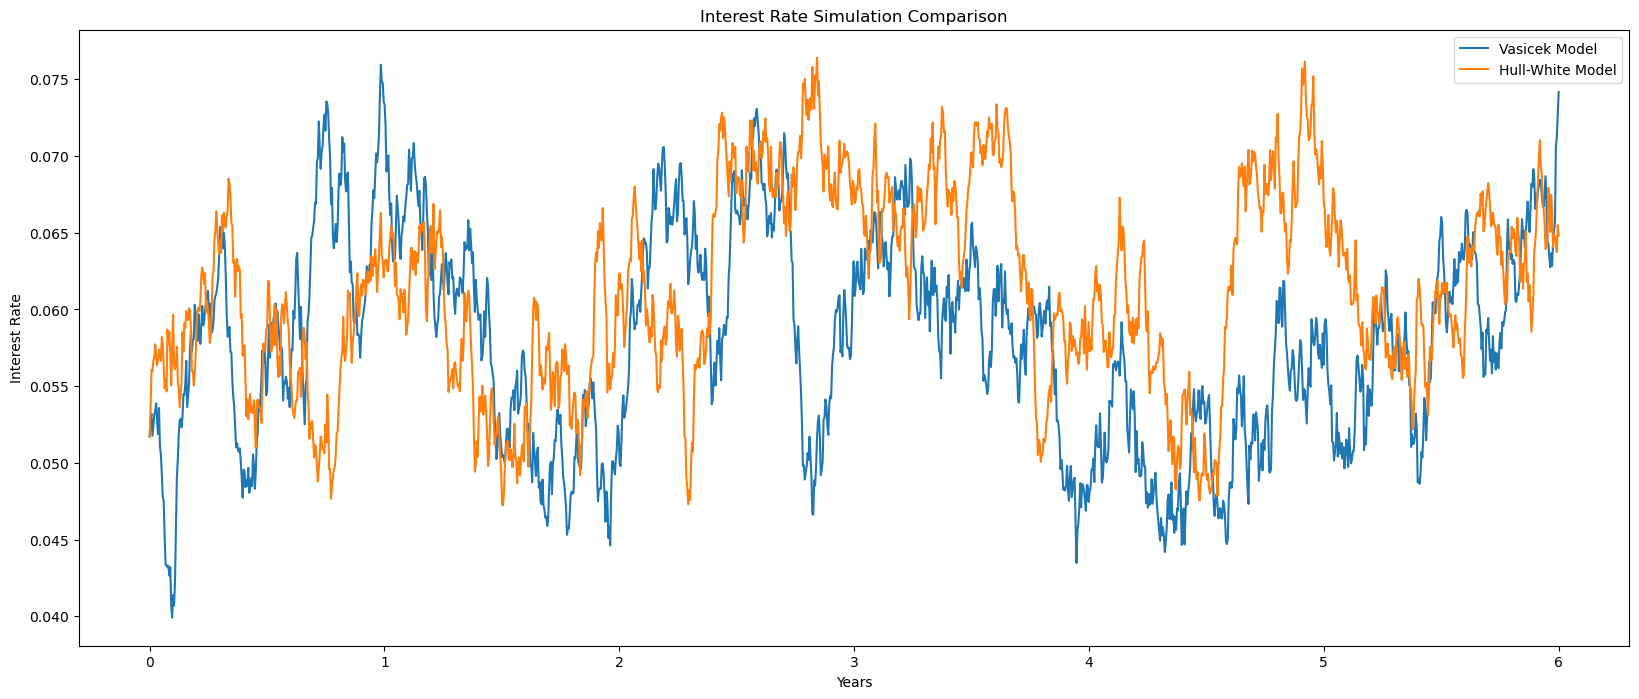

In [26]:
plt.figure(figsize=(20,8))

plt.plot(time, vasicek_rates, label="Vasicek Model")
plt.plot(time, hw_rates, label="Hull-White Model")

plt.xlabel("Years")
plt.ylabel("Interest Rate")

plt.title("Interest Rate Simulation Comparison")

plt.legend()

plt.show()

In [25]:
periods = [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5]

print("Predicted Interest Rates\n")

for p in periods:

    idx = int(p/T * steps)

    print("Year:", p)
    print("Vasicek:", vasicek_rates[idx])
    print("Hull-White:", hw_rates[idx])
    print()

Predicted Interest Rates

Year: 0.5
Vasicek: 0.05468732609736975
Hull-White: 0.05881048637061024

Year: 1
Vasicek: 0.0733056187382139
Hull-White: 0.06308430664045764

Year: 1.5
Vasicek: 0.050374424181278146
Hull-White: 0.04726373264545755

Year: 2
Vasicek: 0.049982646584209305
Hull-White: 0.06236221395500971

Year: 2.5
Vasicek: 0.06645244835727371
Hull-White: 0.06833441327181247

Year: 3
Vasicek: 0.060878244837899845
Hull-White: 0.06692247230499904

Year: 3.5
Vasicek: 0.06564766392026168
Hull-White: 0.06992670110798511

Year: 4
Vasicek: 0.04814774441652797
Hull-White: 0.05727233215019249

Year: 4.5
Vasicek: 0.05348059729921514
Hull-White: 0.048896275962845875

Year: 5
Vasicek: 0.05901095549643821
Hull-White: 0.06660247994196539

Year: 5.5
Vasicek: 0.06563114449736314
Hull-White: 0.061723210742197686



In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Semi-annual maturities
times = np.array([0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,5.5])

# Vasicek predicted rates
vasicek_rates = np.array([
    0.054687326, 0.073305618, 0.050374424, 0.049982646,
    0.066452448, 0.060878244, 0.065647664, 0.048147744,
    0.053480597, 0.059010955, 0.065631144
])

# Hull-White predicted rates
hw_rates = np.array([
    0.058104864, 0.063084306, 0.047263733, 0.062362214,
    0.068334413, 0.066922472, 0.069926701, 0.057273323,
    0.048896276, 0.066602480, 0.061723211
])

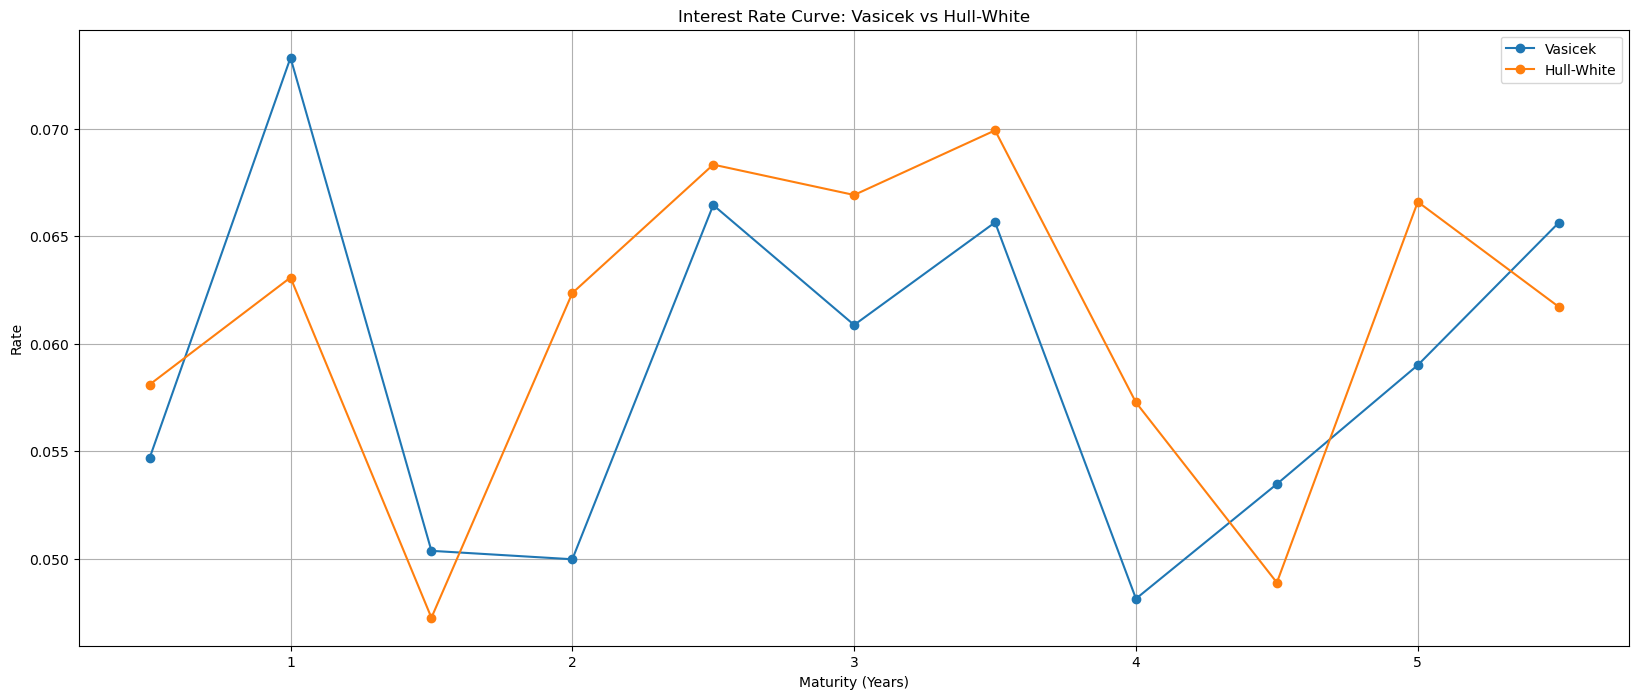

In [46]:
plt.figure(figsize=(20,8))

plt.plot(times, vasicek_rates, marker='o', label='Vasicek')
plt.plot(times, hw_rates, marker='o', label='Hull-White')

plt.title("Interest Rate Curve: Vasicek vs Hull-White")
plt.xlabel("Maturity (Years)")
plt.ylabel("Rate")
plt.legend()
plt.grid()

plt.show()

In [47]:
FV = 1000000                            # Face Value
coupon_rate = 0.08                      #Coupon rate (Annual)

coupon = FV * coupon_rate / 2   # semi-annual
n_periods = 20

bond_times = np.arange(0.5, 10.5, 0.5)
cashflows = np.full(n_periods, coupon)
cashflows[-1] += FV                     #Last Payment include: FV + Coupon

In [48]:
from scipy.interpolate import interp1d

vas_interp = interp1d(times, vasicek_rates, fill_value="extrapolate")         #Function that gives int rate at any time (Vasicek)
hw_interp = interp1d(times, hw_rates, fill_value="extrapolate")               #Function that gives int rate at any time (Hull White)

vas_curve = vas_interp(bond_times)  #Vacisek rate curve
hw_curve = hw_interp(bond_times)    #HUll white rate curve

In [49]:
def bond_price(rates):                                        #Bond pricing formula: PV= CF/(1+r/m)^t

    discount = 1 / (1 + rates/2) ** (2 * bond_times)
    pv = cashflows * discount
    
    return np.sum(pv)

In [50]:
def duration(rates):

    discount = 1 / (1 + rates/2) ** (2 * bond_times)
    pv = cashflows * discount
    
    price = np.sum(pv)
    
    return np.sum(bond_times * pv) / price

In [51]:
def compute_dv01(rates_curve):         #DV01: Dollar value of 1 basis point

    results = []                       #Create empty list, will stocke DV01 for the years

    for sp in [1,2,3,4,5]:             #For 5 years

        rates_up = rates_curve.copy()
        rates_down = rates_curve.copy()

        idx = np.argmin(np.abs(bond_times - sp))       #Index of maturity closest to sp

        rates_up[idx] += 0.0001                        #Int rate shift
        rates_down[idx] -= 0.0001

        price_up = bond_price(rates_up)
        price_down = bond_price(rates_down)

        dv01 = (price_down - price_up) / 2

        results.append(dv01)

    return results

In [52]:
vas_dv01 = compute_dv01(vas_curve)
hw_dv01 = compute_dv01(hw_curve)

comparison = pd.DataFrame({
    "Maturity": [1,2,3,4,5],
    "DV01_Vasicek": vas_dv01,
    "DV01_HullWhite": hw_dv01
})

print(comparison)

   Maturity  DV01_Vasicek  DV01_HullWhite
0         1      3.590542        3.644174
1         2      7.071134        6.861440
2         3      9.728030        9.530637
3         4     12.916309       12.409721
4         5     14.524953       13.948694


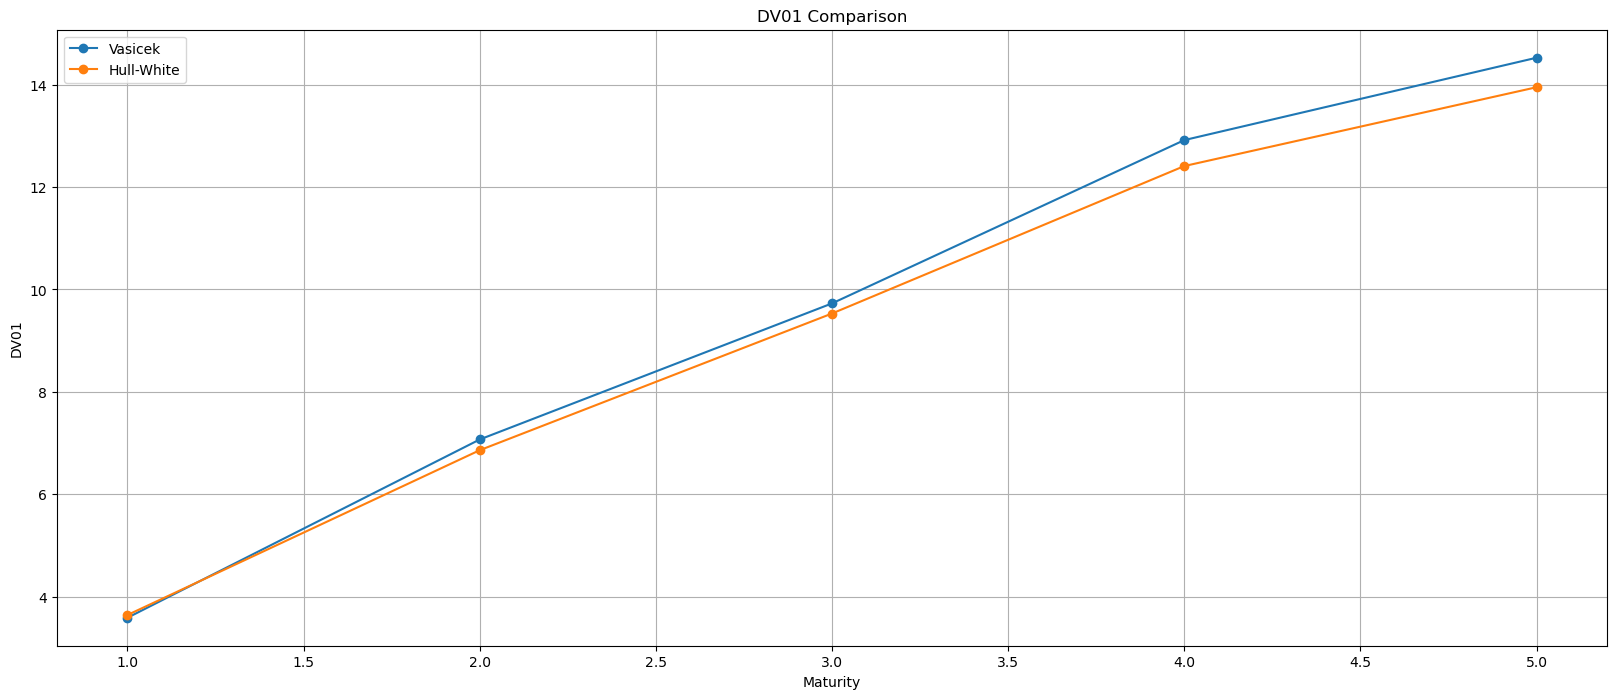

In [54]:
plt.figure(figsize=(20,8))

plt.plot(comparison["Maturity"], comparison["DV01_Vasicek"], marker='o', label='Vasicek')
plt.plot(comparison["Maturity"], comparison["DV01_HullWhite"], marker='o', label='Hull-White')

plt.title("DV01 Comparison")
plt.xlabel("Maturity")
plt.ylabel("DV01")
plt.legend()
plt.grid()

plt.show()